# Case Study 2 — SOLUTION: Early Warning System

Reference solution for `case2_early_warning.ipynb`. Uses `data/case2_early_warning.csv.xz`
(application + bureau + "early window" behavioural features, target
`EARLY_WARNING_SEGMENT`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "data"
df = pd.read_csv(f"{DATA_DIR}/case2_early_warning.csv.xz")
print(df.shape)
df.head()


(292076, 48)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,POS_EARLY_PCT_DPD_GT0,CC_EARLY_MAX_UTILIZATION,CC_EARLY_MEAN_UTILIZATION,CC_EARLY_MEAN_DRAWINGS,CC_EARLY_MAX_DPD_DEF,INSTAL_EARLY_NUM_PAYMENTS,INSTAL_EARLY_PCT_LATE,INSTAL_EARLY_MEAN_DAYS_LATE,INSTAL_EARLY_MEAN_PAYMENT_RATIO,EARLY_WARNING_SEGMENT
0,100002,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0.0,NaN,NaN,NaN,NaN,13.0,0.000000,-22.000000,1.00,Immediate Attention
1,100003,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,NaN,NaN,NaN,NaN,25.0,0.000000,-7.160000,1.00,Low Risk
2,100004,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,NaN,NaN,NaN,NaN,3.0,0.000000,-7.666667,1.00,Low Risk
3,100006,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0.0,NaN,NaN,NaN,NaN,9.0,0.000000,-29.000000,1.00,Low Risk
4,100007,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,NaN,NaN,NaN,NaN,60.0,0.266667,-3.883333,0.95,Low Risk


## Task 1 — Load & Explore

In [2]:
order = ["Low Risk", "Medium Risk", "High Risk", "Immediate Attention"]
counts = df["EARLY_WARNING_SEGMENT"].value_counts().reindex(order)
print(counts)
print((counts / len(df)).round(4))


EARLY_WARNING_SEGMENT
Low Risk               246176
Medium Risk             19011
High Risk                2894
Immediate Attention     23995
Name: count, dtype: int64
EARLY_WARNING_SEGMENT
Low Risk               0.8428
Medium Risk            0.0651
High Risk              0.0099
Immediate Attention    0.0822
Name: count, dtype: float64


`High Risk` (~1%) and `Medium Risk` (~6.5%) are rare compared to `Low Risk` (~84%) and
`Immediate Attention` (~8%). Overall **accuracy** would be dominated by the `Low Risk`
majority class — a model that mostly predicts `Low Risk` could still score high accuracy
while completely missing the rare-but-actionable `Medium`/`High Risk` segments. Better
metrics: **macro-averaged F1** (treats all classes equally) and **per-class recall**,
especially for `High Risk`/`Immediate Attention`.

In [3]:
behavioral_cols = [c for c in df.columns if c.startswith(("POS_EARLY", "CC_EARLY", "INSTAL_EARLY"))]
df[behavioral_cols].isna().mean().sort_values(ascending=False)


CC_EARLY_MAX_UTILIZATION           0.732624
CC_EARLY_MEAN_UTILIZATION          0.732624
CC_EARLY_MEAN_DRAWINGS             0.730865
CC_EARLY_MAX_DPD_DEF               0.730865
POS_EARLY_NUM_RECORDS              0.022135
POS_EARLY_PCT_DPD_GT0              0.022135
POS_EARLY_MAX_DPD_DEF              0.022135
POS_EARLY_MEAN_DPD                 0.022135
POS_EARLY_MAX_DPD                  0.022135
INSTAL_EARLY_MEAN_PAYMENT_RATIO    0.017406
INSTAL_EARLY_MEAN_DAYS_LATE        0.017396
INSTAL_EARLY_PCT_LATE              0.017382
INSTAL_EARLY_NUM_PAYMENTS          0.017382
dtype: float64

Missingness here is **informative, not random**: e.g. `CC_EARLY_*` is missing for a
customer who never had a credit card product, and `POS_EARLY_*`/`INSTAL_EARLY_*` is missing
for someone with no point-of-sale loan or installment history in the early window. This
itself is a signal (a customer with no behavioural footprint differs from one with a clean
history) — so we add explicit "has history" indicator flags rather than just imputing
silently.

## Task 2 — Feature Preparation

In [4]:
# Indicator flags for "has early-window history" per product type
df["HAS_POS_EARLY"] = df["POS_EARLY_NUM_RECORDS"].notna().astype(int)
df["HAS_CC_EARLY"] = df["CC_EARLY_MAX_UTILIZATION"].notna().astype(int)
df["HAS_INSTAL_EARLY"] = df["INSTAL_EARLY_NUM_PAYMENTS"].notna().astype(int)

from sklearn.model_selection import train_test_split

df["EARLY_WARNING_SEGMENT"] = pd.Categorical(df["EARLY_WARNING_SEGMENT"], categories=order, ordered=True)
y = df["EARLY_WARNING_SEGMENT"].cat.codes  # 0=Low Risk ... 3=Immediate Attention

feature_cols = [c for c in df.columns if c not in ("SK_ID_CURR", "EARLY_WARNING_SEGMENT")]
X = df[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cat_cols = X.select_dtypes(include="object").columns.tolist()
for c in cat_cols:
    X_train[c] = X_train[c].astype("category")
    X_val[c] = pd.Categorical(X_val[c], categories=X_train[c].cat.categories)

print(X_train.shape, X_val.shape, "| categoricals:", len(cat_cols))


(233660, 49) (58416, 49) | categoricals: 10


/tmp/ipykernel_52050/2652735972.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


Missing numeric behavioural values are left as `NaN` and handled natively by LightGBM
(which learns an optimal split direction for missing values), rather than imputed with e.g.
0 — a 0 utilization and a *missing* (never had a card) utilization mean very different things.

## Task 3 — Multi-Class Model & Evaluation

In [5]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix

clf = lgb.LGBMClassifier(
    objective="multiclass", num_class=4, n_estimators=300,
    learning_rate=0.05, num_leaves=31, class_weight="balanced",
    random_state=42, verbose=-1,
)
clf.fit(X_train, y_train, categorical_feature=cat_cols)
y_pred = clf.predict(X_val)

print(classification_report(y_val, y_pred, target_names=order))


                     precision    recall  f1-score   support

           Low Risk       0.93      0.55      0.69     49236
        Medium Risk       0.14      0.39      0.21      3802
          High Risk       0.03      0.34      0.06       579
Immediate Attention       0.20      0.53      0.29      4799

           accuracy                           0.54     58416
          macro avg       0.33      0.45      0.31     58416
       weighted avg       0.81      0.54      0.62     58416



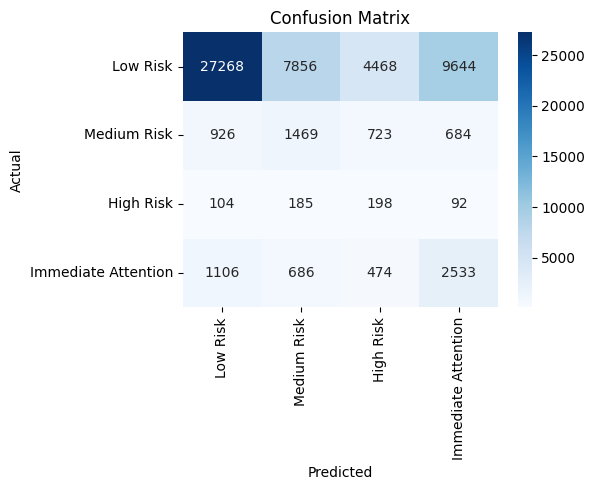

In [6]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


**Which error is worse?** Missing an `Immediate Attention` customer by predicting
`Low Risk` (a **false negative** on the highest-risk class) is far more costly — the bank
takes no action and the account deteriorates/defaults unchecked. A `Low Risk` customer
flagged as `Immediate Attention` (a **false positive**) only costs an unnecessary outreach.

To reflect this, you'd: (a) keep `class_weight="balanced"` or weight `Immediate Attention`
even more heavily, and/or (b) instead of taking `argmax` of the predicted probabilities,
lower the probability threshold required to assign `Low Risk` — i.e. bias the decision
rule toward flagging borderline cases for review rather than letting them default to
"no action."

## Task 4 — What Predicts Deterioration?

In [7]:
importances = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15)


ORGANIZATION_TYPE                  5997
INSTAL_EARLY_MEAN_DAYS_LATE        1687
EXT_SOURCE_3                       1510
EXT_SOURCE_2                       1491
INSTAL_EARLY_PCT_LATE              1462
OCCUPATION_TYPE                    1458
POS_EARLY_NUM_RECORDS              1275
EXT_SOURCE_1                       1240
BUREAU_DAYS_CREDIT_MEAN            1229
DAYS_BIRTH                         1199
INSTAL_EARLY_NUM_PAYMENTS          1128
AMT_ANNUITY                        1049
AMT_GOODS_PRICE                    1046
BUREAU_AMT_CREDIT_SUM_TOTAL        1046
INSTAL_EARLY_MEAN_PAYMENT_RATIO    1037
dtype: int32

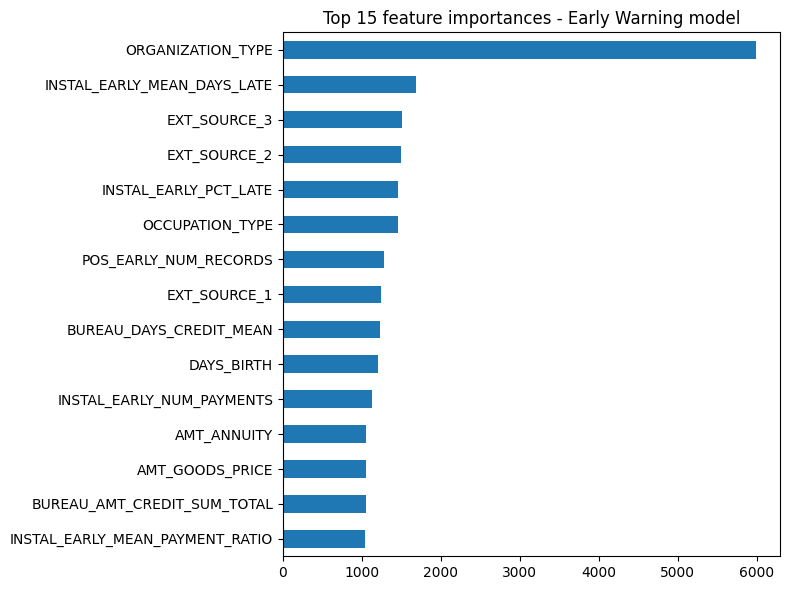

In [8]:
plt.figure(figsize=(8, 6))
importances.head(15).iloc[::-1].plot(kind="barh")
plt.title("Top 15 feature importances - Early Warning model")
plt.tight_layout()
plt.show()


Behavioural early-window signals (`INSTAL_EARLY_PCT_LATE`, `POS_EARLY_MAX_DPD`/`MAX_DPD_DEF`,
`CC_EARLY_MAX_UTILIZATION`) typically rank highly — a customer who was *already* showing
mild lateness or high utilization a year ago is more likely to deteriorate further.
Application/bureau features (`EXT_SOURCE_*`, income ratios, `BUREAU_*`) still contribute,
especially for customers with little/no early-window product history (`HAS_*` flags = 0),
where behavioural signals don't exist yet. In practice, **both layers add value** —
behavioural features dominate when present, demographic/bureau features fill the gap
otherwise.

## Task 5 — From Prediction to Action

**Proposed actions per segment:**
- **Medium Risk** -> Automated check-in (email/SMS) reminding of upcoming payments;
  no human cost, catches early slippage before it compounds.
- **High Risk** -> Proactive outreach from a relationship/retention team — offer a
  restructured payment plan or temporary payment holiday before the account misses
  payments badly enough to reach `Immediate Attention`.
- **Immediate Attention** -> Route directly to collections/specialist team for active
  management; this segment is already on a trajectory toward default by the time of
  scoring.

**Threshold discussion:** Predicting a customer's risk as *lower* than their true segment
(e.g. true `High Risk` predicted as `Low Risk`) means a deteriorating account gets **no**
intervention — directly costly (missed early-warning value). Predicting *higher* than true
(e.g. true `Low Risk` predicted as `Medium Risk`) just triggers a cheap automated check-in —
low cost. Since under-prediction is far more costly than over-prediction, the decision
thresholds should be **biased toward flagging more accounts for at least the lightest-touch
intervention** — i.e. require a *high* predicted probability of `Low Risk` before taking no
action at all, rather than simply taking the argmax class.

## Task 6 — Stretch: Segment Stability

In [9]:
# Collapse to binary: does the customer need ANY attention (Medium/High/Immediate) vs Low Risk?
y_train_binary = (y_train > 0).astype(int)
y_val_binary = (y_val > 0).astype(int)

clf_binary = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight="balanced", random_state=42, verbose=-1,
)
clf_binary.fit(X_train, y_train_binary, categorical_feature=cat_cols)
y_pred_binary = clf_binary.predict(X_val)

print(classification_report(y_val_binary, y_pred_binary, target_names=["Low Risk", "Needs Attention"]))


                 precision    recall  f1-score   support

       Low Risk       0.91      0.68      0.78     49236
Needs Attention       0.28      0.66      0.39      9180

       accuracy                           0.68     58416
      macro avg       0.60      0.67      0.59     58416
   weighted avg       0.81      0.68      0.72     58416



In [10]:
importances_binary = pd.Series(clf_binary.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances_binary.head(10)


ORGANIZATION_TYPE              1465
EXT_SOURCE_2                    481
EXT_SOURCE_3                    462
INSTAL_EARLY_MEAN_DAYS_LATE     434
EXT_SOURCE_1                    398
INSTAL_EARLY_NUM_PAYMENTS       359
AMT_GOODS_PRICE                 359
INSTAL_EARLY_PCT_LATE           346
AMT_ANNUITY                     342
POS_EARLY_NUM_RECORDS           317
dtype: int32

Collapsing the rare `Medium`/`High Risk` classes together with `Immediate Attention` into a
single "needs attention" class gives the model far more positive examples to learn from
(~16% vs. ~1-6.5% for the individual rare classes), generally improving recall on the
classes that matter operationally. The top features are usually similar (behavioural
lateness/DPD/utilization dominate), but their relative ranking can shift — with more
balanced classes, application/bureau features sometimes gain relative importance because
the model is no longer almost entirely driven by separating the dominant `Low Risk` class.